## ReLU MLP Single-Phase Experiments

This notebook runs a standard fully connected ReLU network with a single training phase only.

It trains across multiple seeds and reports start/end metrics plus aggregate statistics.

No dropout, normalization, or multi-phase logic is used.

In [ ]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from first_experiment.odt import generate_cob_odt_data
from first_experiment.training import set_seed
from first_experiment.relu_mlp import ReLUMLP
from first_experiment.relu_training import (
    ReLUTrainConfig,
    evaluate_relu_mlp,
    train_relu_mlp,
)

# Scratch-aligned defaults with a plain ReLU MLP.
DIM = 100
DEPTH = 5
N_TRAIN = 80_000
HIDDEN_DIMS = [40, 40, 40]

TOTAL_EPOCHS = 2000
LR = 2e-3
BATCH_SIZE = 80
WEIGHT_DECAY = 0.01


def quadratic_snapshot_epochs(total_epochs: int, n_points: int = 80) -> tuple[int, ...]:
    """Dense near init, sparser later via quadratic growth."""
    if n_points < 2:
        return (0, total_epochs)
    vals = []
    for i in range(n_points):
        frac = i / (n_points - 1)
        vals.append(int(round((frac**2) * total_epochs)))
    vals.extend([0, total_epochs])
    return tuple(sorted(set(vals)))


SNAPSHOT_EPOCHS = range(TOTAL_EPOCHS)
print(f"Using {len(SNAPSHOT_EPOCHS)} snapshot epochs.")
print("First 15:", SNAPSHOT_EPOCHS[:15])
print("Last 10:", SNAPSHOT_EPOCHS[-10:])

MASTER_SEEDS = [5178]

all_results = {}

Using 2000 snapshot epochs.
First 15: range(0, 15)
Last 10: range(1990, 2000)


## Training and evaluation helpers

These helpers define BCE-with-logits training, deterministic data/model seeding, checkpoint snapshots, and evaluation metrics.

In [54]:
def run_single_seed(master_seed: int) -> dict:
    data_seed = master_seed
    init_seed = master_seed + 1000
    train_seed = master_seed + 2000

    x, y, tree, meta = generate_cob_odt_data(
        num_data=2 * N_TRAIN,
        dim=DIM,
        depth=DEPTH,
        seed=data_seed,
        threshold=0.0,
    )
    x_train, y_train = x[:N_TRAIN], y[:N_TRAIN]
    x_eval, y_eval = x[N_TRAIN:], y[N_TRAIN:]

    set_seed(init_seed)
    model = ReLUMLP(input_dim=DIM, hidden_dims=HIDDEN_DIMS, bias=True)
    out = train_relu_mlp(
        model=model,
        x_train=x_train,
        y_train=y_train,
        config=ReLUTrainConfig(
            epochs=TOTAL_EPOCHS,
            lr=LR,
            batch_size=BATCH_SIZE,
            seed=train_seed,
            snapshot_epochs=SNAPSHOT_EPOCHS,
            weight_decay=WEIGHT_DECAY,
            show_progress=True,
            lr_scheduler_eta_min_ratio=0.05,
        ),
    )

    return {
        "master_seed": master_seed,
        "seeds": {"data_seed": data_seed, "init_seed": init_seed, "train_seed": train_seed},
        "tree": tree,
        "meta": meta,
        "data": {"x_train": x_train, "y_train": y_train, "x_eval": x_eval, "y_eval": y_eval},
        "out": out,
    }


def collect_start_end_metrics(seed_result: dict) -> list[dict]:
    out = seed_result["out"]
    ckpts = out["checkpoint_snapshots"]
    epochs_sorted = sorted(ckpts.keys())
    e0, eN = epochs_sorted[0], epochs_sorted[-1]

    x_train = seed_result["data"]["x_train"]
    y_train = seed_result["data"]["y_train"]
    x_eval = seed_result["data"]["x_eval"]
    y_eval = seed_result["data"]["y_eval"]

    model = copy.deepcopy(out["model"])
    rows = []
    for label, ep in [("start", e0), ("end", eN)]:
        model.load_state_dict(ckpts[ep])
        m_tr = evaluate_relu_mlp(model=model, x_eval=x_train, y_eval=y_train)
        m_te = evaluate_relu_mlp(model=model, x_eval=x_eval, y_eval=y_eval)
        rows.append(
            {
                "timepoint": label,
                "epoch": ep,
                "train_log_loss": m_tr["log_loss"],
                "test_error": m_te["zero_one_loss"],
            }
        )
    return rows

## Run all seeds

This is the expensive cell. It runs single-phase ReLU MLP training for each master seed.

In [55]:
for seed in MASTER_SEEDS:
    print(f"Running seed {seed} ...")
    all_results[seed] = run_single_seed(seed)
print("Done")

Running seed 5178 ...


Training ReLU MLP:   0%|          | 0/2001 [00:00<?, ?it/s]

Done


## Scatter plot and gating dynamics analysis

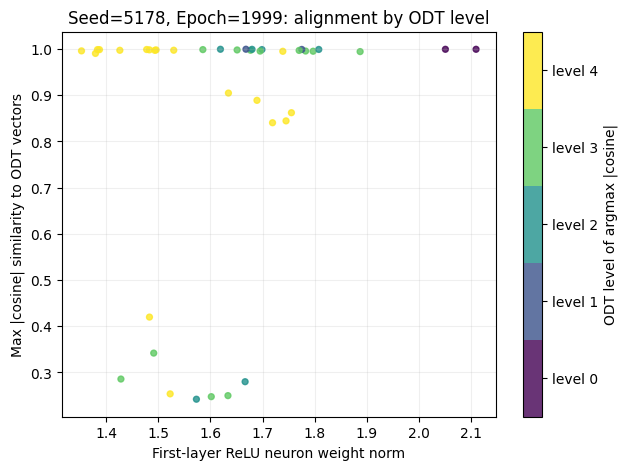

In [65]:
MSEED = MASTER_SEEDS[0]

out = all_results[MSEED]["out"]
ckpts = out["checkpoint_snapshots"]
tree = all_results[MSEED]["tree"]
EPOCH =  list(ckpts.keys())[1999] # choose from SNAPSHOT_EPOCHS

if EPOCH not in ckpts:
    raise ValueError(f"EPOCH {EPOCH} not in checkpoints. Available: {sorted(ckpts.keys())}")

# First hidden-layer weights: shape (num_neurons, input_dim)
first_layer_wts = ckpts[EPOCH]["hidden_layers.0.weight"].detach().cpu()

# ODT hyperplane normals: shape (num_odt_nodes, input_dim)
odt_wts = torch.from_numpy(tree.w_list).float()

# Neuron norms for x-axis
row_norms = first_layer_wts.norm(dim=1)

# Cosine similarity matrix: (num_neurons, num_odt_nodes)
cos = (first_layer_wts @ odt_wts.T) / (
    row_norms.unsqueeze(1).clamp_min(1e-12)
    * odt_wts.norm(dim=1).unsqueeze(0).clamp_min(1e-12)
)

abs_cos = cos.abs()
max_abs_cos, closest_odt = abs_cos.max(dim=1)
# closest_odt: tensor shape (num_neurons,), each value in [0, num_internal_nodes-1]
closest_odt_np = closest_odt.numpy()
# For heap-indexed complete binary tree: level = floor(log2(node_id + 1))

node_level = np.floor(np.log2(closest_odt_np + 1)).astype(int)
# labels for legend
level_names = {
    0: "level 0",
    1: "level 1",
    2: "level 2",
    3: "level 3",
    4: "level 4",
}
# plot with 5 discrete colors
cmap = plt.get_cmap("viridis", DEPTH)  # DEPTH=5 -> 5 colors
plt.figure(figsize=(7, 5))
sc = plt.scatter(
    row_norms.numpy(),
    max_abs_cos.numpy(),
    c=node_level,
    cmap=cmap,
    s=18,
    alpha=0.8,
    vmin=-0.5,
    vmax=DEPTH - 0.5,
)
cbar = plt.colorbar(sc, ticks=range(DEPTH))
cbar.ax.set_yticklabels([level_names[i] for i in range(DEPTH)])
cbar.set_label("ODT level of argmax |cosine|")
plt.xlabel("First-layer ReLU neuron weight norm")
plt.ylabel("Max |cosine| similarity to ODT vectors")
plt.title(f"Seed={MSEED}, Epoch={EPOCH}: alignment by ODT level")
plt.grid(alpha=0.2)
plt.show()


## Aggregate analysis

This block computes per-seed start/end metrics, then aggregates mean/std across seeds for single-phase training.

In [62]:
# plt.plot(all_results[6178]["out"]["epoch_losses"])
rows = []
for seed, seed_result in all_results.items():
    for r in collect_start_end_metrics(seed_result):
        rows.append({"master_seed": seed, **r})

per_seed_table = pd.DataFrame(rows).sort_values(["master_seed", "timepoint"]).reset_index(drop=True)
agg_table = (
    per_seed_table.groupby(["timepoint"], as_index=False)
    .agg(
        n=("master_seed", "count"),
        train_log_loss_mean=("train_log_loss", "mean"),
        train_log_loss_std=("train_log_loss", "std"),
        test_error_mean=("test_error", "mean"),
        test_error_std=("test_error", "std"),
    )
    .sort_values(["timepoint"])
    .reset_index(drop=True)
)

display(per_seed_table)
display(agg_table)

,master_seed,timepoint,epoch,train_log_loss,test_error
0,5178,end,1999,0.021791,0.044025
1,5178,start,0,0.696069,0.498587


,timepoint,n,train_log_loss_mean,train_log_loss_std,test_error_mean,test_error_std
0,end,1,0.021791,NaN,0.044025,NaN
1,start,1,0.696069,NaN,0.498587,NaN


## Quick visualization

Bar plots for start vs end test error and train log loss means across seeds.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(agg_table["timepoint"], agg_table["test_error_mean"])
axes[0].set_title("Test error (mean)")

axes[1].bar(agg_table["timepoint"], agg_table["train_log_loss_mean"])
axes[1].set_title("Train log loss (mean)")

plt.tight_layout()
plt.show()